In [22]:
""" 1.1.1 """

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

X, y = data.data, data.target

#print("data type: ", type(data))

#print("data keys: ", data.keys())

#569 row 30 column
#print("shape of X: ", X.shape)

#569 tarket
#print("shape of Y: ", y.shape)

#two type of targets
#print("target names: ", data.target_names)

#the feature names
#print("feature names: ", data.feature_names)

"""we are going to use stratify since the splitting should include more equal classes """
#splitting 30 to 70 test and train dataset, temp values are for test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
)

#splitting validation and test into half, taken them from x temp and y temp above
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
)

#the shape of the train, test and validation datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (398, 30)
y_train shape: (398,)
X_val shape: (85, 30)
y_val shape: (85,)
X_test shape: (86, 30)
y_test shape: (86,)


malignant: 212
benign: 357
Train: (array([0, 1]), array([149, 249]))
Validation: (array([0, 1]), array([37, 48]))
Test: (array([0, 1]), array([26, 60]))

Basic statistics for the first three features:
mean radius -> mean: 14.1273, std: 3.5210
mean texture -> mean: 19.2896, std: 4.2973
mean perimeter -> mean: 91.9690, std: 24.2776


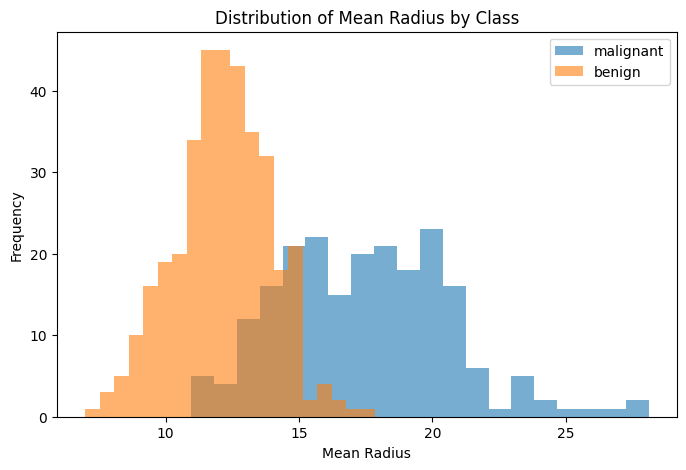

In [23]:
""" 1.1.2 """
#class distribtuion
classes, counts = np.unique(y, return_counts=True)

print("malignant:", counts[0])
print("benign:", counts[1])

#to look at the label distribution we can do such thing:
print("Train:", np.unique(y_train, return_counts=True))
print("Validation:", np.unique(y_val, return_counts=True))
print("Test:", np.unique(y_test, return_counts=True))

# 2. Basic statistics for the first three features
print("\nBasic statistics for the first three features:")
for i in range(3):
    feature_name = data.feature_names[i]
    feature_mean = np.mean(X[:, i])
    feature_std = np.std(X[:, i])
    print(f"{feature_name} -> mean: {feature_mean:.4f}, std: {feature_std:.4f}")

# 3. Histogram of mean radius by class
mean_radius = X[:, 0]

plt.figure(figsize=(8, 5))
plt.hist(mean_radius[y == 0], bins=20, alpha=0.6, label="malignant")
plt.hist(mean_radius[y == 1], bins=20, alpha=0.6, label="benign")

plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Radius by Class")
plt.legend()
plt.show()

In [24]:
""" 1.1.3 """

scaler = StandardScaler()

scaler = preprocessing.StandardScaler().fit(X_train)

X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

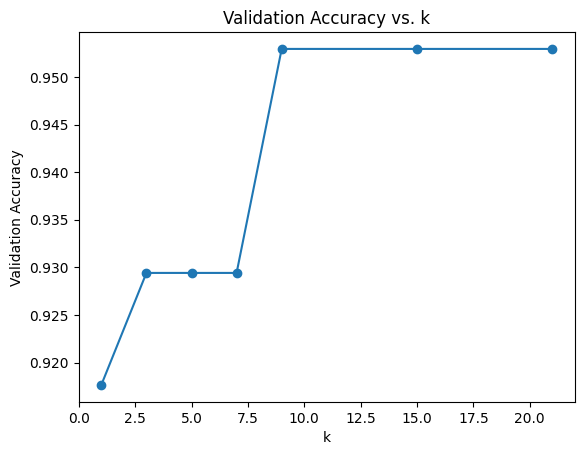

In [25]:
""" 1.2.1 """

k = [1, 3, 5, 7, 9, 15, 21]

val_accuracy = []
for i in k:
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train, y_train)
    validation_prediction = model.predict(X_val)
    acc = accuracy_score(y_val, validation_prediction)
    val_accuracy.append(acc)

plt.plot(k, val_accuracy, marker='o')
plt.xlabel('k')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs. k')
plt.show()


Test Accuracy: 0.9883720930232558
Confusion Matrix:
[[25  1]
 [ 0 60]]


Text(0.5, 1.0, 'Confusion Matrix for Final k-NN Model')

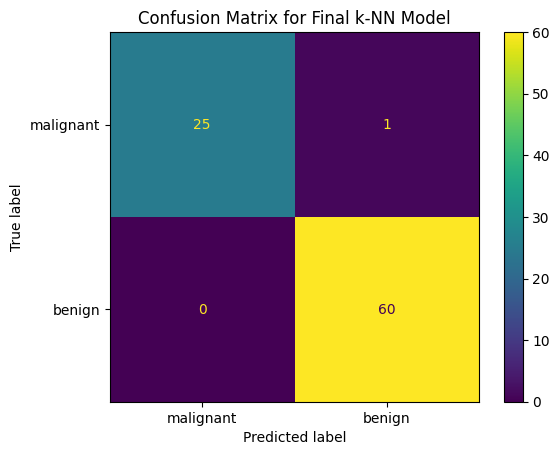

In [26]:
""" 1.2.2 """,
#we combine training and validation sets
X_train_val = np.concatenate((X_train, X_val), axis=0)
y_train_val = np.concatenate((y_train, y_val), axis=0)

final_model = KNeighborsClassifier(n_neighbors=9)
final_model.fit(X_train_val, y_train_val)

test_prediction = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_prediction)
print("Test Accuracy:", test_accuracy)

confussion_mtrx = confusion_matrix(y_test, test_prediction)
print("Confusion Matrix:")
print(confussion_mtrx)


visualize = ConfusionMatrixDisplay(confusion_matrix=confussion_mtrx, display_labels=data.target_names)
visualize.plot()
plt.title("Confusion Matrix for Final k-NN Model")


max_depth=2, min_samples_split=2, validation_accuracy=0.9176
max_depth=2, min_samples_split=5, validation_accuracy=0.9176
max_depth=2, min_samples_split=10, validation_accuracy=0.9176
max_depth=4, min_samples_split=2, validation_accuracy=0.9647
max_depth=4, min_samples_split=5, validation_accuracy=0.9412
max_depth=4, min_samples_split=10, validation_accuracy=0.9412
max_depth=6, min_samples_split=2, validation_accuracy=0.9647
max_depth=6, min_samples_split=5, validation_accuracy=0.9529
max_depth=6, min_samples_split=10, validation_accuracy=0.9529
max_depth=8, min_samples_split=2, validation_accuracy=0.9412
max_depth=8, min_samples_split=5, validation_accuracy=0.9412
max_depth=8, min_samples_split=10, validation_accuracy=0.9294
max_depth=None, min_samples_split=2, validation_accuracy=0.9412
max_depth=None, min_samples_split=5, validation_accuracy=0.9412
max_depth=None, min_samples_split=10, validation_accuracy=0.9294

Best hyperparameter combination:
Best max_depth: 4
Best min_samples_sp

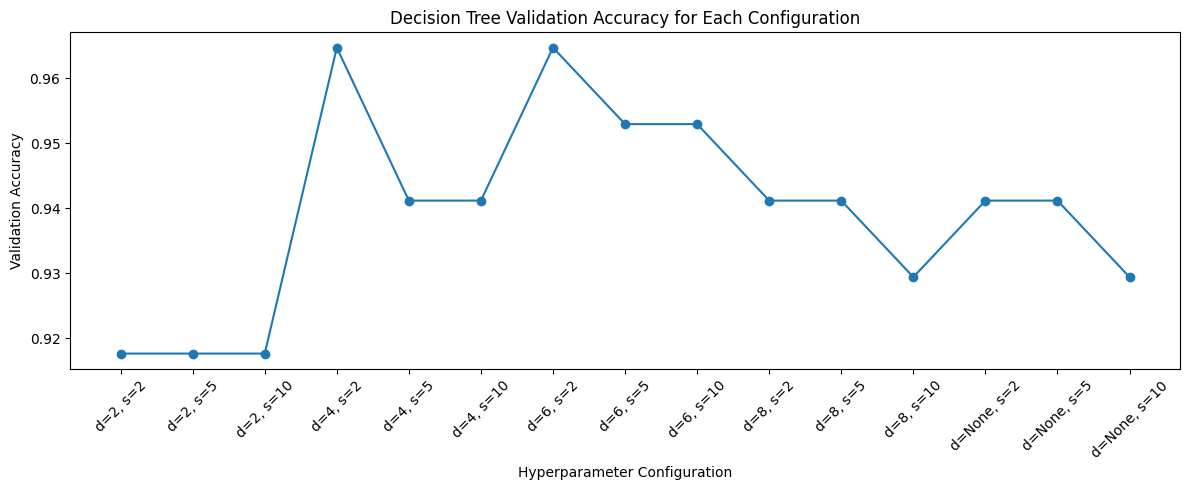

In [27]:
"1.3.1"


max_depth_values = [2, 4, 6, 8, None]
min_samples_split_values = [2, 5, 10]

results = []

for depth in max_depth_values:
    for min_split in min_samples_split_values:
        model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=min_split,
            random_state=42
        )

        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        acc = accuracy_score(y_val, y_val_pred)

        results.append((depth, min_split, acc))

for depth, min_split, acc in results:
    print(f"max_depth={depth}, min_samples_split={min_split}, validation_accuracy={acc:.4f}")

best_result = max(results, key=lambda x: x[2])
best_depth, best_min_split, best_val_acc = best_result

print("\nBest hyperparameter combination:")
print("Best max_depth:", best_depth)
print("Best min_samples_split:", best_min_split)
print("Best validation accuracy:", best_val_acc)



labels = []
accuracies = []

for depth, min_split, acc in results:
    labels.append(f"d={depth}, s={min_split}")
    accuracies.append(acc)

plt.figure(figsize=(12, 5))
plt.plot(labels, accuracies, marker='o')
plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Validation Accuracy")
plt.title("Decision Tree Validation Accuracy for Each Configuration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Test Accuracy: 0.9534883720930233
Confusion Matrix:
[[24  2]
 [ 2 58]]


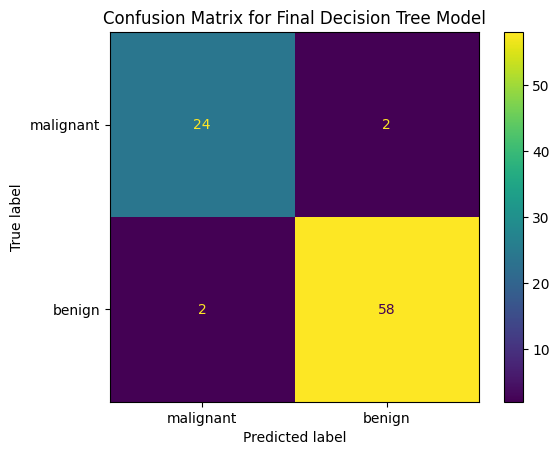

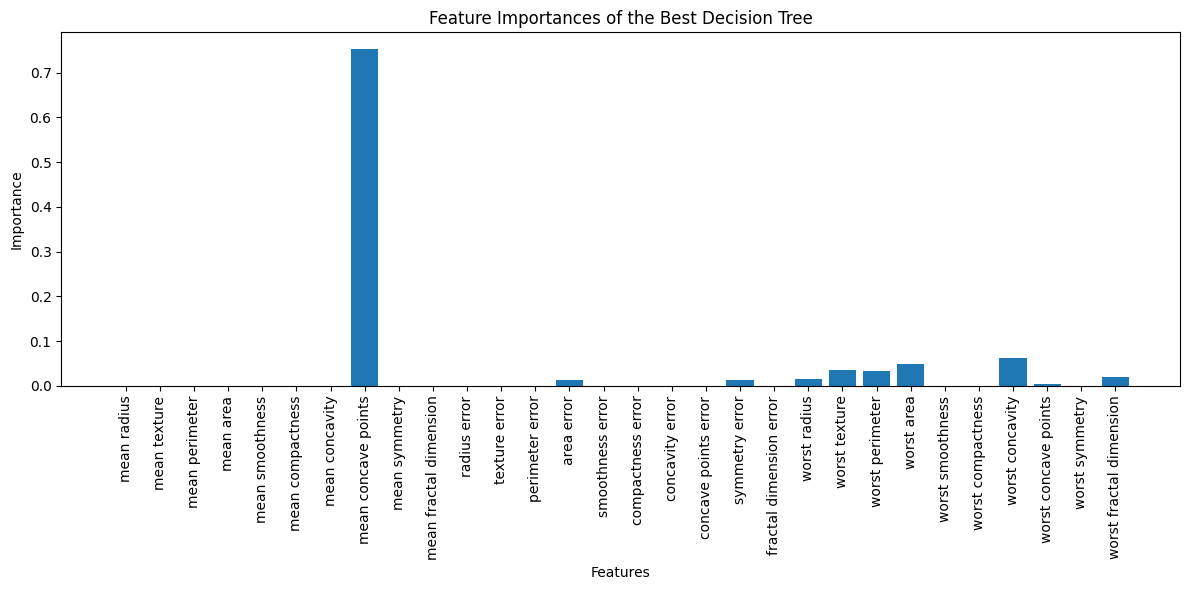

In [28]:
" 1.3.2 "

X_train_val = np.concatenate((X_train, X_val), axis=0)
y_train_val = np.concatenate((y_train, y_val), axis=0)

dt = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_min_split,
    random_state=42
)

dt.fit(X_train_val, y_train_val)

y_test_prediction2 = dt.predict(X_test)
test_acc = accuracy_score(y_test, y_test_prediction2)

print("Test Accuracy:", test_acc)

confusion_matrix2 = confusion_matrix(y_test, y_test_prediction2)
print("Confusion Matrix:")
print(confusion_matrix2)

visualize2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix2, display_labels=data.target_names)
visualize2.plot()
plt.title("Confusion Matrix for Final Decision Tree Model")


importances = dt.feature_importances_
feature_names = data.feature_names

plt.figure(figsize=(12, 6))
plt.bar(feature_names, importances)
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importances of the Best Decision Tree")
plt.tight_layout()
plt.show()